### Q2: At what time-interval would you be least certain about how many runs there will be in the game? (Choose a 1-minute time interval--there can be many answers here).

So the deliverable is **a specific one-minute window**, quoted as a timestamp, not a method. The "many answers" hint tells us different reasonable measures will select different minutes, and that showing that disagreement - with the reasoning for each - is to be expected. We will therefore report the winning minute under each measure separately, and then nominate one as the headline answer.

#### Universe: the KXMLBTOTAL chain, 11 strikes

`KXMLBTOTAL` is runs scored in the game by both teams combined, which is exactly what
the question asks about. `F5TOTAL` covers only five innings, `TEAMTOTAL` covers one
team, and `RFI` covers one inning, so none of them answer it. Strikes run n = 2 to 12,
giving 11 markets.

#### Step 1 -- survival curve to PMF

Each contract is a survival probability S(n) = P(runs >= n). Differencing adjacent
strikes gives the probability mass function. With strikes only spanning 2 to 12, the
result has 12 buckets, two of which are censored lumps:

| bucket | formula | size observed in this dataset |
| --- | --- | --- |
| runs <= 1 | 1 - S(2) | 3.0% - 3.5% |
| runs = n, for n = 2..11 | S(n) - S(n+1) | the interior |
| runs >= 12 | S(12) | 14.5% - 15.5% |

The head lump is small enough to ignore. The tail lump is not -- roughly 15% of the
mass sits in an open-ended bucket, and we cannot know how it splits across 12, 13, 14+.
This is the single biggest reason the choice of metric below matters.

Q1 established there are no monotonicity violations anywhere in this chain, so every
differenced bucket is guaranteed non-negative and the PMF is always well formed.

**The two functions this needs.** The walk calls these at every event where the gate
passes, so they are written once and kept small:

1. `get_total_ladder(cache)` -- pull the KXMLBTOTAL strikes out of the cache and return
   them as an array ordered by strike ascending, S(2) through S(12). It selects only the
   `KXMLBTOTAL` chain (not F5TOTAL, TEAMTOTAL or RFI, whose names also start with
   `KXMLB`), parses the strike number off the end of each ticker, sorts by it, and
   returns the 11 mid prices in that order. It should assert that exactly 11 strikes
   came back, because a silently short ladder would produce a PMF that looks fine and is
   wrong.

2. `ladder_to_pmf(S)` -- turn that survival ladder into the 12-bucket PMF by
   differencing adjacent strikes:

   ```
   pmf = [1 - S[0]]  +  [S[i] - S[i+1] for i in 0..9]  +  [S[10]]
       =  P(runs <= 1),  P(runs = 2..11),  P(runs >= 12)
   ```

   In numpy this is `np.concatenate([[1 - S[0]], -np.diff(S), [S[-1]]])`. The sum
   telescopes to exactly 1 by construction, so it needs no renormalising, and Q1's
   result that this chain is monotone everywhere means no bucket can come out negative.
   Assert both anyway -- they are one line each, and if either ever fails it means the
   ladder was assembled in the wrong order.

Everything downstream -- entropy, variance, E[runs] -- is computed from the output of
`ladder_to_pmf`, so the survival-to-PMF conversion lives in exactly one place.

#### Step 2 -- the three metrics, and why these

**(1) Entropy of the PMF -- how wide is the market's belief?**  `H = -sum p*log2(p)`,
in bits.

This is the information-theoretic definition of uncertainty, which is what the question
is asking about. Its decisive advantage here is that entropy is invariant to what the
outcomes are *called* -- it only cares how mass is spread across buckets. So the
`runs >= 12` lump is simply one bucket among twelve and **never has to be assigned a
numeric value**. That removes the tail problem entirely rather than papering over it.

The cost of that same property: entropy does not know that 5 runs is nearer to 6 than to
12. A distribution on {5,6} and one on {2,12} have identical entropy but very different
uncertainty about *how many* runs. That is the one thing variance knows and entropy does
not, which is why variance is kept below as a sensitivity check rather than deleted.

**(2) Movement in E[runs] -- how hard is the market revising?**  `E[runs] = sum[n*p(n)]`,
tracked as a time series across the whole window, with movement measured as the change
from one valid observation to the next.

Entropy measures how wide the market's belief is; this measures how much it is being
revised. If E[runs] holds at 7.3 for an hour and then steps to 7.44, that step marks a
minute in which the market changed its mind about the forecast.
Because the whole dataset is pregame -- no runs have been scored, so nothing can update
the distribution except lineups, weather and order flow -- we expect the *level*
measures to be nearly flat and the *churn* measure to carry most of the discrimination.
The note below explains why we measure how much E[runs] changed from one minute to the
next, instead of how much it bounced around inside a single minute.

E[runs] does require a numeric value for the `>= 12` bucket. We will place it at 13 and
report the sensitivity of the answer to 12 / 13 / 14, the same way Q1 reported
sensitivity to the freshness threshold.

**(3) Mean staleness of the PMF -- how well do we even observe the market?**  Walking
forward in time, keep a cache with one entry per strike holding the timestamp at which
we last saw a quote for it. At any instant, each strike's age is the current timestamp
minus its last-seen timestamp, and the PMF's staleness is the **average** of those 11
ages.

This measures something genuinely different from (1) and (2): not the market's
uncertainty about runs, but *our* uncertainty about where the market is. Both are
legitimate readings of "least certain". A minute in which no strike has been quoted for several minutes
is a minute in which we could not confidently price anything, which is a real and
practical form of uncertainty.

*Why average and not max.* Consider two edge cases. In 1-minute interval A, we saw 10 of
the 11 strikes quoted just 1 minute ago, and the 11th strike is a laggard where we saw
its quote 10 minutes ago. Max would call this whole PMF 10 minutes stale -- but in
reality, we can be pretty sure where the 11th strike should be priced, given information
about the other 10 strikes (some interpolation based on how historically those 11
strikes relate to each other should solve for the 11th missing strike). Now consider
1-minute interval B, where all 11 strikes are missing and all of them were last seen 7
minutes ago. Max would rank this PMF as being 7 minutes stale, which is fresher and more
up to date than A. But I have seen zero strikes quoted for the past 7 minutes, and I
could argue convincingly that I know less about where the market is in case B.
Average gets both right: A scores 1.8 minutes and B scores 7.0.

A mass-weighted version -- weighting each strike by the probability mass it governs, so
a stale S(7) counts for more than a stale S(12) -- is a sensible refinement to add
later. Start with the simple average.

**Sensitivity check, not a headline metric: variance of the PMF.**
`Var = sum n^2*p(n) - (sum n*p(n))^2`. Reported alongside entropy to show the two agree,
but not used as the primary answer, because variance weights by squared distance from
the mean and roughly 15% of the mass is in an open-ended tail bucket. The answer would
partly reflect our invented tail placement rather than the market.

#### A measure considered and dropped: bid-ask spread width

We considered bid-ask spread width as a possible candidate -- makers widen their quotes
when they are uncertain -- but given that **96.4% of book rows on this chain are 1 cent
wide and the remaining 3.6% are 2 cents**, with nothing wider, there is no variation to
exploit. A measure taking two distinct values across 21,543 observations cannot
meaningfully rank 360 minutes, so it is not used.

#### Step 3 -- when is the PMF even defined?

Entropy, E[runs] and variance all require **all 11 strikes simultaneously** -- a ladder
cannot be differenced if it is only partly observed. But the strikes do not update
together: they are quoted at different times, so at most instants some are current and
others are minutes old.

Instead, the PMF is **only defined when every one of the 11 strikes is fresher than a
staleness threshold**, set to **10 seconds** by default and exposed as a parameter so
the whole analysis can be re-run at other values. The gate uses the **oldest** of the 11 ages. Metric (3) reports the **average**. Step 4
explains why each is used where it is. Same discipline as the Q1 arbitrage
check: only compare quotes we actually observed close together in time.

Coverage at various thresholds, measured on this dataset:

| threshold | valid instants | share of chain events | minutes with >= 1 valid observation |
| --- | --- | --- | --- |
| <= 1s | 3,573 | 9.5% | 202 / 360 (56.1%) |
| <= 2s | 4,415 | 11.8% | 207 / 360 (57.5%) |
| <= 5s | 6,516 | 17.4% | 223 / 360 (61.9%) |
| **<= 10s** | **9,961** | **26.5%** | **259 / 360 (71.9%)** |
| <= 30s | 24,452 | 65.1% | 321 / 360 (89.2%) |
| <= 60s | 31,715 | 84.5% | 339 / 360 (94.2%) |

At the 10-second default, **101 of the 360 minutes have no valid PMF at all**, so
entropy and E[runs] movement are undefined there and are reported as missing rather
than filled.

We can loosen the threshold to 30 seconds, which would raise the percentage of time that a PMF is well-defined to almost 90%, but the tradeoff there is that we are taking quotes which are half a minute old and assuming that they are still valid (tradeable), which is exactly the opposite of the goal of this question (to identify when we are uncertain about the market).  In reality, for an end-user's goals, they can customize where they want to set the threshold for the strikes/pieces of a PMF to be "too stale to be trustworthy."

#### The shape of the answer: two tiers of uncertainty

The gate above is not just a data-hygiene step, it decides the structure of the answer.
There are two different kinds of not-knowing here, and they are not on the same scale.

**Tier 1 -- the market is unobservable.** If the last quotes we have for the 11 strikes
are far enough in the past, we cannot say where the market is pricing the expected
number of runs. Not "we can say it imprecisely" -- we literally cannot produce a number,
because there is no PMF to compute one from. These are the most uncertain intervals in
the dataset, and metric (3) is what identifies them. This is where a trader's judgement
differs from a statistician's: the temptation is to carry the stale quotes forward and
keep reporting a variance or an entropy as though nothing were wrong, which produces a
confident-looking number describing a market we cannot actually see. Refusing to compute
it is the more honest answer, and the refusal itself is the finding.

**Tier 2 -- the market is observable, and we can argue about how wide or how unstable
it is.** Among the intervals where all 11 strikes were fresh enough to derive a PMF, we
then rank on entropy, on variance, and on how much E[runs] moved. These are finer
distinctions drawn between minutes we could actually see.

So the answer is reported in that order: first the intervals where no PMF exists at all,
then the ranking among the intervals where one does.

#### A note on how the three metrics differ in kind

Entropy and variance are **snapshot** quantities. Each is computed from a single PMF at
a single instant, and mapping them to a one-minute interval just means averaging the
snapshots that fall inside it. A high-entropy minute is one where, at the moments we
could see the market, its belief was spread widely across outcomes.

E[runs] is **not** a measure of uncertainty on its own. A market pricing E[runs] = 7.4
is not more or less certain than one pricing 6.1 -- it is simply forecasting a different
number. The value carries no information about confidence. E[runs] only becomes a
measure of uncertainty when we look at how it **moves**: how much it wiggles inside a
minute, where it spikes or crashes, how far it travels relative to its usual step size.
A minute in which E[runs] is dragged from 7.30 to 7.44 and back is a minute in which the
market is actively disagreeing with itself about the forecast, and that is the sense in
which it is uncertain.

The right way is to treat E[runs] as a **time series over the whole six hours**. As the
walk moves from `start_time` to `end_time`, E[runs] is computed whenever the staleness
test passes and stored against its timestamp, leaving NaN wherever the PMF could not be
built. That yields one series showing how the market's forecast wandered across the
session, with visible holes where we could not see it. From that series we look at where
it actually moved: plot it, then locate the intervals containing the largest changes
from one valid observation to the next. Movement is therefore measured **between**
intervals, as a first difference along the series, not **within** an interval as a
dispersion statistic. The level of E[runs] is carried only as context, never as a
ranking measure.

#### Step 4 -- walk-forward logic over 1-minute intervals

1. Take `start_time` and `end_time` as the min and max of `recv_ts_utc` across the
   `KXMLBTOTAL` chain. Here that is 17:35:34 to 23:34:41 UTC, 5.99 hours, giving
   **360 one-minute bins**. Use `recv_ts_utc`, not exchange time, because that is when
   the information was actually available to us.
2. Build left-closed, right-open bins: `[start, start+1min)`, `[start+1min,
   start+2min)`, ... through `end_time`. Label each bin by its left edge.
3. Walk the book feed once in chronological order, holding a cache keyed by strike,
   each entry storing that strike's latest quote and the timestamp at which we saw it --
   exactly as the Q1 arbitrage engine does. Ages are always derived from those
   timestamps, never stored, so there is one source of truth to keep updated.
   Evaluate on each arriving chain event rather than on a fixed clock grid -- the feed
   is event-driven, so this samples the market when it actually moved. The dict holds
   the last quote seen per strike and its timestamp; it is a lookup of what we last
   observed, not a resampled or filled time series.
4. At each event, derive the age of all 11 strikes from the cache -- age is
   `current event timestamp - last_seen[strike]`. Record the mean age unconditionally;
   that is metric (3), and it is defined at every instant after warm-up. If and only if the
   **maximum** age is within the freshness threshold (all 11 strikes less than 10
   seconds old) do we call `get_total_ladder` and `ladder_to_pmf` from Step 1 to build
   the PMF, then compute entropy, variance and E[runs] from it.
   Append each result keyed on its timestamp, so the walk itself produces a tidy pandas
   frame: `mean_staleness` and `max_staleness` on every row, and `entropy`, `variance`
   and `E_runs` only on the rows that passed the gate, NaN elsewhere.
   *Note on the two uses of staleness.* Max and mean are both used on the same 11 ages. They do not contradict each other --
each answers a different question.
   The **max is a gate**: the PMF requires all 11 strikes at once, so its validity is
   decided by the weakest leg, and one strike older than the threshold means there is no
   PMF at all no matter how fresh the other ten are. That is deliberate -- we would
   rather report nothing than guess at E[runs] from a ladder we cannot fully see. The
   **mean is a description**: it says how old our picture of the chain is on average,
   and it is what ranks the Tier 1 minutes against each other. Max cannot do that job,
   because among minutes that have already failed the gate it is driven by whichever
   single strike lagged worst -- case A above, where ten fresh strikes and one laggard
   would be scored as badly as eleven strikes all gone quiet. So: max decides *whether*
   we can compute anything, mean measures *how well* we were seeing the market.

5. Reduce to one row per one-minute interval. The result is a DataFrame indexed by the
   360 minute bins, with four columns: E_runs, entropy, variance, mean_staleness

   The first three are the PMF metrics and share a fate: **where no valid PMF could be
   built anywhere inside the minute, all three are NaN.** Those NaNs are not missing
   data to be patched; they are the primary result. `mean_staleness` sits in the same
   frame rather than a separate one because it is metric (3) itself, and because it is
   the column that ranks the minutes where the other three are absent -- the two have to
   be side by side to report Tier 1 at all.

6. Report in two tiers.
   - *Tier 1:* the minutes whose `E_runs`, `entropy` and `variance` are all NaN, ranked
     by `mean_staleness`. These are the intervals where the market could not be observed
     well enough to state an expected number of runs at all, and they are the most
     uncertain intervals in the dataset.
   - *Tier 2:* among the minutes that do carry values, rank by entropy (widest belief)
     and separately by the size of the change in `E_runs` from the previous valid minute
     (largest repricing). Note where the two agree and where they disagree, since the
     question invites more than one answer.

### Running it -- the minute frame

The functions live in `utils.py`, in the block headed `Q2`. Nothing below re-derives
anything: `walk_total_chain` makes the single chronological pass, `minute_frame` reduces
its output to one row per minute.

In [11]:
import numpy as np
import pandas as pd

from utils import (walk_total_chain,        # the one pass over the KXMLBTOTAL chain
                   minute_frame,            # event stream -> 360 one-minute rows
                   tier1_minutes,           # the minutes with no PMF at all
                   tier2_minutes,           # the minutes that do carry one
                   plot_q2_series,          # the four series, gaps left as gaps
                   q2_threshold_sensitivity, # the walk re-run at other gates
                   market_short_name,       # native_id -> 'KXMLBTOTAL-8'
                   parse_chain_and_strike,  # 'KXMLBTOTAL-8' -> ('TOTAL', 8)
                   TOTAL_CHAIN)

df_books = pd.read_parquet("data/orderbook_data_823753_pregame.parquet")

events  = walk_total_chain(df_books, freshness_seconds = 10.0, tail_value = 13.0)
minutes = minute_frame(events)

print(f"chain events after warm-up : {len(events):,}")
print(f"instants passing the gate  : {events['E_runs'].notna().sum():,}")
print(f"one-minute bins            : {len(minutes)}")
print(f"  carrying a PMF           : {minutes['E_runs'].notna().sum()}")
print(f"  Tier 1, no PMF at all    : {minutes['E_runs'].isna().sum()}")

chain events after warm-up : 37,551
instants passing the gate  : 9,961
one-minute bins            : 360
  carrying a PMF           : 259
  Tier 1, no PMF at all    : 101


#### The 360 x 4 frame

One row per minute across the whole window. `mean_staleness` is populated everywhere;
`E_runs`, `entropy` and `variance` are NaN wherever the 11 strikes were never
simultaneously fresh enough inside that minute.

In [12]:
pd.set_option("display.max_rows", 400)
pd.set_option("display.float_format", "{:,.4f}".format)

minutes.head(n = 5)

,E_runs,entropy,variance,mean_staleness
recv_ts_utc,,,,
2026-08-05 17:35:00+00:00,7.4350,3.4081,11.6858,9.2868
2026-08-05 17:36:00+00:00,NaN,NaN,NaN,18.5046
2026-08-05 17:37:00+00:00,NaN,NaN,NaN,25.1871
2026-08-05 17:38:00+00:00,NaN,NaN,NaN,34.5465
2026-08-05 17:39:00+00:00,NaN,NaN,NaN,57.4040


In [13]:
minutes.tail(n = 5)

,E_runs,entropy,variance,mean_staleness
recv_ts_utc,,,,
2026-08-05 23:30:00+00:00,7.3100,3.4627,11.8639,2.4661
2026-08-05 23:31:00+00:00,7.3050,3.4599,11.8820,11.8948
2026-08-05 23:32:00+00:00,7.3000,3.4632,11.9100,17.9933
2026-08-05 23:33:00+00:00,7.3000,3.4632,11.9100,9.7109
2026-08-05 23:34:00+00:00,7.3000,3.4632,11.9100,9.0409


#### Validation against the pre-measured targets

These targets were measured straight from the data before any of this was written. If
the implementation matches the plan, it reproduces them exactly.


In [14]:
targets = {
    "chain events after warm-up": (len(events),                          37_551),
    "valid instants":             (int(events["E_runs"].notna().sum()),   9_961),
    "minute bins":                (len(minutes),                            360),
    "minutes with a value":       (int(minutes["E_runs"].notna().sum()),    259),
    "Tier 1 minutes":             (int(minutes["E_runs"].isna().sum()),     101),
}
for name, (got, want) in targets.items():
    print(f"{name:<28} {got:>8,}   target {want:>8,}   {'OK' if got == want else 'MISMATCH'}")

print()
for col, lo, hi in [("entropy", 3.4048, 3.4657),
                    ("E_runs",  7.3000, 7.4350),
                    ("variance", 11.4860, 11.9100)]:
    got_lo, got_hi = events[col].min(), events[col].max()
    ok = round(got_lo, 4) == lo and round(got_hi, 4) == hi
    print(f"{col:<10} {got_lo:8.4f} - {got_hi:8.4f}   "
          f"target {lo:8.4f} - {hi:8.4f}   {'OK' if ok else 'MISMATCH'}")

chain events after warm-up     37,551   target   37,551   OK
valid instants                  9,961   target    9,961   OK
minute bins                       360   target      360   OK
minutes with a value              259   target      259   OK
Tier 1 minutes                    101   target      101   OK

entropy      3.4048 -   3.4657   target   3.4048 -   3.4657   OK
E_runs       7.3000 -   7.4350   target   7.3000 -   7.4350   OK
variance    11.4860 -  11.9100   target  11.4860 -  11.9100   OK


#### The four series over time

Four panels sharing one time axis. **Nothing is interpolated across the gaps** -- the
blank stretches in the top three panels are the Tier 1 minutes, where the chain was too
stale for a PMF to exist, and those blanks are the answer rather than missing data.
`mean_staleness` is drawn on every minute, so it is continuous: it is what tells us how
badly we were seeing the market during the stretches where the other three go blank.

Markers are drawn as well as lines so an isolated valid minute surrounded by NaN is
still visible; with a line alone it would have no segment to draw and would disappear.

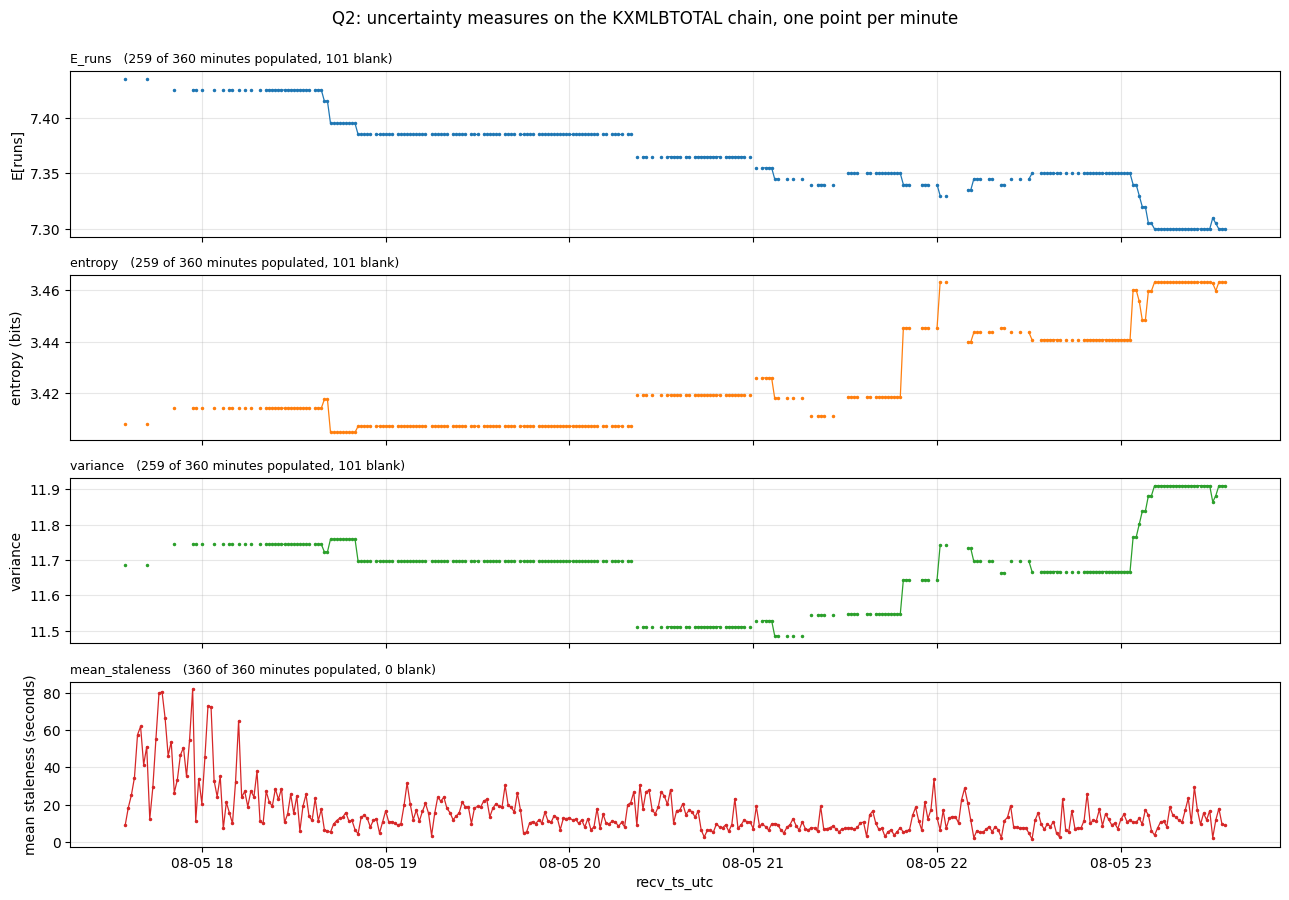

In [15]:
fig, axes = plot_q2_series(minutes)

#### Tier 1 -- the minutes where no PMF exists at all

The primary answer. These are the minutes in which the eleven strikes were never
simultaneously fresh, so no expected number of runs can be stated -- not imprecisely,
but at all. Ranked by mean staleness, for the reason given in Step 4: among minutes that
have already failed the gate, max is driven by whichever single strike lagged worst.

Consecutive Tier 1 minutes are grouped into blackouts, because a six-minute stretch of
blindness is a stronger answer than six unrelated minutes that happen to rank highly.


In [16]:
t1 = tier1_minutes(minutes)
print(f"Tier 1: {len(t1)} of {len(minutes)} minutes carry no PMF at all")

# Consecutive Tier 1 minutes form one blackout; group them so the answer is a
# stretch of blindness rather than a set of unrelated high-ranking minutes.
blank  = minutes["E_runs"].isna()
run_id = (blank != blank.shift()).cumsum().rename("blackout")

runs = (minutes[blank]
        .groupby(run_id[blank])
        .agg(start          = ("mean_staleness", lambda s: s.index[0]),
             end            = ("mean_staleness", lambda s: s.index[-1]),
             n_minutes      = ("mean_staleness", "size"),
             mean_staleness = ("mean_staleness", "mean")))

print(f"forming {len(runs)} separate blackouts\n")
print("Longest blackouts:")
runs.sort_values(["n_minutes", "mean_staleness"], ascending=False).head(8)


Tier 1: 101 of 360 minutes carry no PMF at all
forming 59 separate blackouts

Longest blackouts:


,start,end,n_minutes,mean_staleness
blackout,,,,
4,2026-08-05 17:43:00+00:00,2026-08-05 17:50:00+00:00,8,52.8583
2,2026-08-05 17:36:00+00:00,2026-08-05 17:41:00+00:00,6,39.8137
98,2026-08-05 22:04:00+00:00,2026-08-05 22:09:00+00:00,6,16.9988
6,2026-08-05 17:52:00+00:00,2026-08-05 17:56:00+00:00,5,44.0882
86,2026-08-05 21:27:00+00:00,2026-08-05 21:30:00+00:00,4,6.7865
10,2026-08-05 18:01:00+00:00,2026-08-05 18:03:00+00:00,3,63.5029
92,2026-08-05 21:52:00+00:00,2026-08-05 21:54:00+00:00,3,14.7991
22,2026-08-05 18:17:00+00:00,2026-08-05 18:18:00+00:00,2,31.0592


#### Tier 2 -- ranking the minutes we could see

Among the 259 minutes that do carry a PMF, the two finer measures: widest belief
(entropy) and largest repricing (the first difference in E[runs] from the previous valid
minute). The question invites more than one answer, so both are reported rather than
collapsed into one.


In [17]:
t2 = tier2_minutes(minutes)
print(f"Tier 2: {len(t2)} minutes carry a PMF\n")

print("Widest belief -- highest entropy:")
print(t2.nlargest(5, "entropy")[["E_runs", "entropy", "variance"]].to_string())

print("\nLargest repricing -- biggest change in E[runs] from the previous valid minute:")
print(t2.assign(abs_move = t2["d_E_runs"].abs())
        .nlargest(5, "abs_move")[["E_runs", "d_E_runs", "entropy"]].to_string())


Tier 2: 259 minutes carry a PMF

Widest belief -- highest entropy:
                           E_runs  entropy  variance
recv_ts_utc                                         
2026-08-05 22:01:00+00:00  7.3300   3.4632   11.7411
2026-08-05 22:03:00+00:00  7.3300   3.4632   11.7411
2026-08-05 23:11:00+00:00  7.3000   3.4632   11.9100
2026-08-05 23:12:00+00:00  7.3000   3.4632   11.9100
2026-08-05 23:13:00+00:00  7.3000   3.4632   11.9100

Largest repricing -- biggest change in E[runs] from the previous valid minute:
                           E_runs  d_E_runs  entropy
recv_ts_utc                                         
2026-08-05 18:42:00+00:00  7.3950   -0.0200   3.4048
2026-08-05 20:22:00+00:00  7.3650   -0.0200   3.4193
2026-08-05 23:09:00+00:00  7.3050   -0.0150   3.4599
2026-08-05 21:07:00+00:00  7.3450   -0.0100   3.4181
2026-08-05 17:51:00+00:00  7.4250   -0.0100   3.4142


#### The 22:04-22:09 blackout, and the hourly picture

The headline answer is the last minute of a six-minute blackout. What makes it the
answer rather than just another gap is that the market was unusually *busy* through it:
a quiet market that nobody is quoting is a weak claim to uncertainty, but a heavily
traded market we cannot price is a strong one.

The hourly table underneath carries the rest of the interpretation -- the entropy climb,
the start-of-window staleness, and the fact that the final hour was the best-observed of
the session rather than the worst.


In [18]:
df_trades = pd.read_parquet("data/trades_823753_pregame.parquet")

for d in (df_books, df_trades):
    d["market"] = d["native_id"].map(market_short_name)
    d["ts"]     = pd.to_datetime(d["recv_ts_utc"], utc=True)

on_chain = lambda m: parse_chain_and_strike(m)[0] == TOTAL_CHAIN
chain_books  = df_books[df_books["market"].map(on_chain)]
chain_trades = df_trades[df_trades["market"].map(on_chain)]

lo = pd.Timestamp("2026-08-05 22:04", tz="UTC")
hi = pd.Timestamp("2026-08-05 22:10", tz="UTC")     # right-open, so 22:04..22:09
span_min = (chain_books["ts"].max() - chain_books["ts"].min()).total_seconds() / 60

window = events.loc[(events.index >= lo) & (events.index < hi)]
in_win = lambda d: d[(d["ts"] >= lo) & (d["ts"] < hi)]

print(f"chain events in 22:04-22:09      : {len(window):,}")
print(f"  passing the freshness gate     : {int(window['E_runs'].notna().sum())}")
print(f"  closest the ladder ever came   : {window['max_staleness'].min():.1f} s"
      f"   (gate is 10.0 s)")
print(f"  quotes per minute              : {len(in_win(chain_books)) / 6:6.1f}"
      f"   session {len(chain_books) / span_min:.1f}")
print(f"  trades per minute              : {len(in_win(chain_trades)) / 6:6.1f}"
      f"   session {len(chain_trades) / span_min:.1f}")

# How far the market moved while we could not see it
valid  = events[events["E_runs"].notna()]
before = valid[valid.index <  lo].iloc[-1]
after  = valid[valid.index >= hi].iloc[0]
rng    = events["entropy"].max() - events["entropy"].min()
print(f"\nentropy last seen before the gap : {before['entropy']:.4f}")
print(f"entropy first seen after the gap : {after['entropy']:.4f}")
print(f"  moved {after['entropy'] - before['entropy']:+.4f} unobserved, "
      f"{abs(after['entropy'] - before['entropy']) / rng:.0%} of the session's range")

hourly = (minutes.assign(hour = minutes.index.floor("H"))
                 .groupby("hour")
                 .agg(entropy        = ("entropy", "mean"),
                      E_runs         = ("E_runs", "mean"),
                      tier1_minutes  = ("E_runs", lambda s: int(s.isna().sum())),
                      mean_staleness = ("mean_staleness", "mean")))
print("\nHour by hour:")
hourly.round(3)


chain events in 22:04-22:09      : 910
  passing the freshness gate     : 0
  closest the ladder ever came   : 12.9 s   (gate is 10.0 s)
  quotes per minute              :  151.7   session 104.6
  trades per minute              :   11.2   session 1.9

entropy last seen before the gap : 3.4632
entropy first seen after the gap : 3.4399
  moved -0.0232 unobserved, 38% of the session's range

Hour by hour:


,entropy,E_runs,tier1_minutes,mean_staleness
hour,,,,
2026-08-05 17:00:00+00:00,3.4120,7.4290,20,43.8530
2026-08-05 18:00:00+00:00,3.4110,7.4120,14,20.1220
2026-08-05 19:00:00+00:00,3.4070,7.3850,8,15.7710
2026-08-05 20:00:00+00:00,3.4150,7.3730,13,13.8130
2026-08-05 21:00:00+00:00,3.4230,7.3470,24,9.3890
2026-08-05 22:00:00+00:00,3.4430,7.3460,22,10.5150
2026-08-05 23:00:00+00:00,3.4590,7.3110,0,12.6860


#### Sensitivity: does the answer depend on our two judgement calls?

Two numbers were chosen rather than measured: the value assigned to the open-ended
`runs >= 12` bucket, and the 10-second freshness gate. Both are reported here rather
than assumed away, the same discipline Q1 applied to its freshness threshold.

The tail value is the one that should worry us, since roughly 15% of the mass sits in
that bucket. Note what it does and does not touch: entropy is invariant to it, because
entropy only cares how mass is spread across buckets and never what they are called,
while E[runs] and variance move with it directly. Tier 1 does not depend on it at all --
those minutes are selected by staleness, which is measured before any PMF is built.


In [19]:
tail_rows = []
for tv in (12.0, 13.0, 14.0):
    ev_tv = walk_total_chain(df_books, freshness_seconds = 10.0, tail_value = tv)
    mi_tv = minute_frame(ev_tv)
    t1_tv = tier1_minutes(mi_tv)
    tail_rows.append({
        "tail_value":    tv,
        "entropy_min":   ev_tv["entropy"].min(),
        "entropy_max":   ev_tv["entropy"].max(),
        "E_runs_min":    ev_tv["E_runs"].min(),
        "E_runs_max":    ev_tv["E_runs"].max(),
        "variance_max":  ev_tv["variance"].max(),
        "tier1_minutes": len(t1_tv),
        "top_tier1":     str(t1_tv.index[0].time()),
    })

print("Tail value for the open-ended `runs >= 12` bucket:")
print(pd.DataFrame(tail_rows).set_index("tail_value").round(4).to_string())

print("\nFreshness gate -- coverage at each threshold "
      "(this reproduces the table in the plan cell):")
q2_threshold_sensitivity(df_books).round(4)


Tail value for the open-ended `runs >= 12` bucket:
            entropy_min  entropy_max  E_runs_min  E_runs_max  variance_max  tier1_minutes top_tier1
tail_value                                                                                         
12.0000          3.4048       3.4657      7.1550      7.2800       10.3810            101  17:47:00
13.0000          3.4048       3.4657      7.3000      7.4350       11.9100            101  17:47:00
14.0000          3.4048       3.4657      7.4450      7.5900       13.6870            101  17:47:00

Freshness gate -- coverage at each threshold (this reproduces the table in the plan cell):


,valid_instants,pct_of_events,minutes_with_value,tier1_minutes,entropy_min,entropy_max,E_runs_min,E_runs_max
threshold_s,,,,,,,,
1.0000,3573,9.5151,202,158,3.4048,3.4657,7.3000,7.4350
2.0000,4415,11.7573,207,153,3.4048,3.4657,7.3000,7.4350
5.0000,6516,17.3524,223,137,3.4048,3.4657,7.3000,7.4350
10.0000,9961,26.5266,259,101,3.4048,3.4657,7.3000,7.4350
30.0000,24452,65.1168,321,39,3.4048,3.4657,7.3000,7.4350
60.0000,31715,84.4585,339,21,3.4048,3.4657,7.3000,7.4350


### Interpretation of graphs:
- **E[runs] did not wiggle, it declined.** The forecast stepped down from 7.435 to 7.300 across the six hours, a total move of 0.135 runs, in discrete steps rather than oscillation. The three largest single-minute repricings were 18:42 UTC (-0.020), 20:22 UTC (-0.020) and 23:09 UTC (-0.015). Note that the level of E[runs] is not itself a measure of uncertainty -- a market forecasting 7.4 runs is no more or less certain than one forecasting 6.1 -- so it is these movements, not the values, that carry information about when the market was revising its view.
- **Entropy and variance both rose toward the end of the session**, with entropy easing slightly over the first three hours and then climbing steadily hour by hour: 3.412, 3.411, 3.407, 3.415, 3.423, 3.443, 3.459. The sharpest steps came after 21:50 and again after 23:00. Since entropy and variance measure the spread of the probability mass function (obtained by differencing adjacent strikes of the survival function, which are the contracts actually traded), this says the market's belief about the run total got *wider* as the game approached, not narrower.
- **That widening is not a market-close effect, and the timing is the interesting part.** The window is entirely pregame: it runs 17:35 to 23:34 UTC, which is 13:35 to 19:34 Eastern, and first pitch is 19:40 Eastern. So the 23:00 UTC hour is the final hour *before* the game starts, when attention should be at its peak, and the data simply ends six minutes short of first pitch. The order book confirms it was the best-observed hour of the whole session: it is the only hour with **zero** Tier 1 minutes, at 12.7s mean staleness. A market where everyone had gone home would look like the opposite. The more plausible reading is that late pregame information -- confirmed lineups, weather, a scratched pitcher, closing betting flow -- genuinely spread the distribution out at exactly the moment the market was watching most closely.
- **Staleness was worst at the very start of the window and settled quickly.** The 17:00 UTC hour averaged 43.9s between refreshes of the full ladder, against roughly 10-20s for the rest of the session. This is the market waking up rather than anything about the game: 17:35 UTC is 13:35 Eastern, six hours before first pitch, so it is the beginning of the data window rather than the morning. That start-of-window effect is a real confound for Tier 1, and it is why the Tier 1 minutes deserve a second look rather than being read straight off the ranking.

### One possible candidate: the least certain 1-minute interval is 22:09 UTC

Taking a single minute, **22:09 UTC** -- the last of a six-minute blackout running 22:04-22:09 UTC. The reasoning:

- **Six straight minutes where no expected number of runs could be computed at all.** All 910 chain events in that stretch failed the freshness gate -- the eleven strikes never lined up within 10 seconds of each other, and the closest the ladder came was 12.9s.
- **It was not a quiet market, which is what makes it the answer.** 152 quotes per minute and 11.2 trades per minute, against session averages of 104.6 and 1.9. Heavy trading, and still nothing you could price off. The longer blackouts earlier (17:36-17:50) are just the market waking up at half normal activity, which is a much weaker answer.
- **The market moved while we were blind.** Entropy went from 3.4632 to 3.4399 across the gap, a move of 38% of the entire session's entropy range, with no way to know when within those six minutes it happened.